# Step 10: Candidate Robustness Validation

Step 09 identified two *clean* candidates for which A and B lose alone, the periodic AB/BA schedules win, the block controls lose, and fewer than half of the tested random schedules win. This notebook asks whether that result is robust rather than a single 100-step parameter coincidence.

The experiment is deliberately split into three interpretable checks:

1. **Duration:** repeat the six deterministic controls over 52, 100, 156, and 260 steps, scaling total budget with duration so that budget intensity per step stays constant.
2. **Local ecology:** perturb growth and diffusion to 75%, 100%, and 125% of each candidate's fitted value.
3. **Schedule specificity:** compare AB/BA with 200 balanced random schedules per candidate.

A candidate is robust in a deterministic scenario only when A, B, A-block-B, and B-block-A all have positive relative change, while AB and BA both have negative relative change.

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os


current_path = Path.cwd().resolve()
repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "src").is_dir()
)
os.chdir(repo_root)

print(f"Repository root: {repo_root}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from utils.data_loader import load_locality_data
from src.experiment_schedules import (
    PolicyParameters,
    balanced_random_schedule,
    budget_exhaustion_step,
    make_scheduled_policy,
    standard_schedules,
)
from src.weed_experiment import ExperimentConfig, run_experiment

c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\cits4403_weed_env_01\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Select the Step 09 candidates

Selection is rule-based so that Step10 remains reproducible if Step09 is rerun: retain every finalist with a positive clean margin and a random-schedule winning fraction below 50%.

In [3]:
finalists_path = repo_root / "results" / "strong_parrondo_finalists.csv"
finalists = pd.read_csv(finalists_path)

candidates = (
    finalists[
        (finalists["clean_margin"] > 0)
        & (finalists["random_winning_fraction"] < 0.5)
    ]
    .sort_values(["clean_margin", "sample_id"], ascending=[False, True])
    .reset_index(drop=True)
)

if candidates.empty:
    raise RuntimeError("Step 09 produced no eligible clean candidates")

candidate_columns = [
    "sample_id", "clean_margin", "random_winning_fraction",
    "growth_rate", "diffusion_rate", "budget",
    "a_rate", "b_rate", "max_cells", "boundary", "b_lower",
]
candidates[candidate_columns]

,sample_id,clean_margin,random_winning_fraction,growth_rate,diffusion_rate,budget,a_rate,b_rate,max_cells,boundary,b_lower
0,2036,0.003486,0.45,0.010,0.0100,250000,0.15,0.65,50,0.7,0.45
1,1370,0.002420,0.45,0.015,0.0025,350000,0.05,0.55,75,0.7,0.40


## 2. Load the study area and configure resumable runs

Both run switches default to `False` to prevent an accidental long run. Set either switch to `True` and rerun from this cell. Results are checkpointed after every scenario or random seed, so an interrupted run can resume without repeating completed simulations.

In [4]:
RUN_DETERMINISTIC = True
RUN_RANDOM = True

DURATIONS = (52, 100, 156, 260)
ECOLOGY_SCALES = (0.75, 1.0, 1.25)
RANDOM_REPLICATES = 200
BASELINE_STEPS = 100
UNIT_COST = 200.0

deterministic_path = repo_root / "results" / "step10_deterministic_robustness.csv"
random_path = repo_root / "results" / "step10_random_schedule_robustness.csv"

localities = load_locality_data(repo_root / "data")
metro = localities[
    localities["postcode"].astype(int).between(6000, 6199)
].copy()

print(f"Candidates: {len(candidates)}")
print(f"Deterministic simulations planned: {len(candidates) * (len(DURATIONS) + len(ECOLOGY_SCALES) ** 2) * 6}")
print(f"Random-schedule simulations planned: {len(candidates) * RANDOM_REPLICATES}")

Candidates: 2
Deterministic simulations planned: 156
Random-schedule simulations planned: 400


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


## 3. Shared experiment functions

The robustness margin is the minimum signed distance from the six required inequalities. It is positive exactly when the strong, clean Parrondo condition holds.

In [5]:
def policy_parameters(row):
    return PolicyParameters(
        a_rate=float(row["a_rate"]),
        b_rate=float(row["b_rate"]),
        max_cells=int(row["max_cells"]),
        boundary=float(row["boundary"]),
        b_lower=float(row["b_lower"]),
        unit_cost=UNIT_COST,
    )


def experiment_config(row, steps, growth_scale=1.0, diffusion_scale=1.0):
    return ExperimentConfig(
        pressure_coef=0.000783,
        cell_size=1000.0,
        w_min=0.05,
        w_max=1.0,
        growth_rate=float(row["growth_rate"]) * growth_scale,
        diffusion_rate=float(row["diffusion_rate"]) * diffusion_scale,
        carrying_capacity=1.0,
        steps=int(steps),
        high_density_threshold=0.7,
        crs="EPSG:7850",
    )


def result_row(candidate, scenario_type, scenario, strategy, config, result):
    budget = float(candidate["budget"])
    return {
        "sample_id": int(candidate["sample_id"]),
        "scenario_type": scenario_type,
        "scenario": scenario,
        "steps": config.steps,
        "growth_rate": config.growth_rate,
        "diffusion_rate": config.diffusion_rate,
        "strategy": strategy,
        "budget": budget,
        "initial_mean": result.initial_mean,
        "final_mean": result.final_mean,
        "relative_change": result.relative_change,
        "winning": result.relative_change < 0,
        "final_cost": result.final_cost,
        "cumulative_weed": float(np.trapezoid(result.mean_weed)),
        "high_density_cells": result.final_high_density_cells,
        "budget_exhaustion_step": budget_exhaustion_step(
            result.cost_history, budget
        ),
    }


def run_deterministic_scenario(candidate, scenario_type, scenario, config):
    rows = []
    parameters = policy_parameters(candidate)
    for strategy, schedule in standard_schedules(config.steps).items():
        result = run_experiment(
            name=f"step10_{int(candidate['sample_id'])}_{scenario}_{strategy}",
            gdf=metro,
            config=config,
            policy=make_scheduled_policy(
                schedule, parameters, float(candidate["budget"])
            ),
        )
        rows.append(
            result_row(
                candidate, scenario_type, scenario, strategy, config, result
            )
        )
    return rows


def scenario_summary(results):
    if results.empty:
        return pd.DataFrame()
    index_columns = [
        "sample_id", "scenario_type", "scenario", "steps",
        "growth_rate", "diffusion_rate",
    ]
    wide = results.pivot(index=index_columns, columns="strategy", values="relative_change")
    wide["robustness_margin"] = pd.concat(
        [
            wide["A only"], wide["B only"],
            wide["A block B"], wide["B block A"],
            -wide["AB"], -wide["BA"],
        ],
        axis=1,
    ).min(axis=1)
    wide["strong_parrondo"] = wide["robustness_margin"] > 0
    return wide.reset_index()

## 4. Deterministic robustness: duration and local ecology

Duration and ecological uncertainty are varied separately. This keeps a failed condition attributable and avoids an opaque full cross-product. Duration budgets are scaled by `steps / 100`, preserving the baseline budget per step. The original 100-step ecology appears in both groups as an intentional consistency check.

In [6]:
if deterministic_path.exists():
    deterministic_results = pd.read_csv(deterministic_path)
else:
    deterministic_results = pd.DataFrame()

completed = set()
if not deterministic_results.empty:
    completed = set(
        deterministic_results[["sample_id", "scenario_type", "scenario"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )

scenario_specs = []
for _, candidate in candidates.iterrows():
    sample_id = int(candidate["sample_id"])
    for steps in DURATIONS:
        duration_candidate = candidate.copy()
        duration_candidate["budget"] = float(candidate["budget"]) * steps / BASELINE_STEPS
        scenario_specs.append(
            (duration_candidate, "duration", f"steps_{steps}", experiment_config(candidate, steps))
        )
    for growth_scale in ECOLOGY_SCALES:
        for diffusion_scale in ECOLOGY_SCALES:
            scenario = f"growth_{growth_scale:.2f}_diffusion_{diffusion_scale:.2f}"
            scenario_specs.append(
                (
                    candidate, "ecology", scenario,
                    experiment_config(
                        candidate, BASELINE_STEPS, growth_scale, diffusion_scale
                    ),
                )
            )

if RUN_DETERMINISTIC:
    for candidate, scenario_type, scenario, config in tqdm(
        scenario_specs, desc="Deterministic scenarios"
    ):
        key = (int(candidate["sample_id"]), scenario_type, scenario)
        if key in completed:
            continue
        new_rows = run_deterministic_scenario(
            candidate, scenario_type, scenario, config
        )
        deterministic_results = pd.concat(
            [deterministic_results, pd.DataFrame(new_rows)], ignore_index=True
        )
        deterministic_results.to_csv(deterministic_path, index=False)
        completed.add(key)

print(f"Deterministic rows available: {len(deterministic_results)}")

Deterministic scenarios: 100%|██████████| 26/26 [00:55<00:00,  2.14s/it]

Deterministic rows available: 156


,sample_id,scenario_type,scenarios,strong_scenarios,minimum_margin,median_margin
0,1370,duration,4,1,-0.005755,-0.003404
1,1370,ecology,9,4,-0.011462,-0.000834
2,2036,duration,4,2,-0.013062,-0.001100
3,2036,ecology,9,5,-0.016136,0.002064


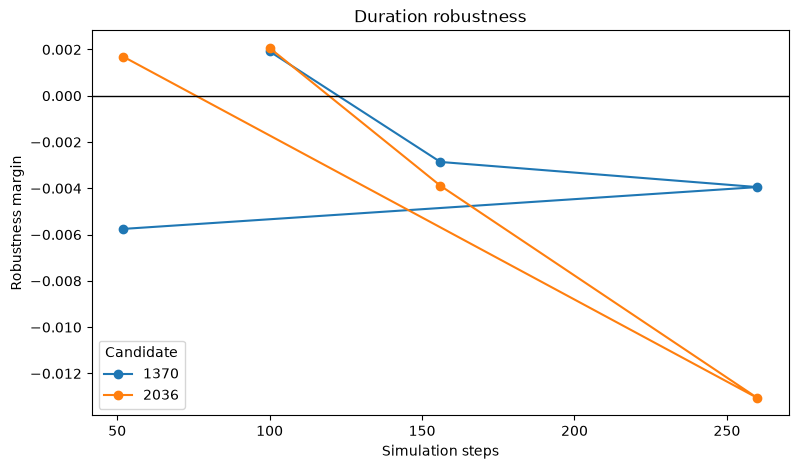

In [7]:
deterministic_summary = scenario_summary(deterministic_results)

if deterministic_summary.empty:
    print("No deterministic results yet. Set RUN_DETERMINISTIC = True and rerun.")
else:
    display(
        deterministic_summary.groupby(["sample_id", "scenario_type"])
        .agg(
            scenarios=("scenario", "count"),
            strong_scenarios=("strong_parrondo", "sum"),
            minimum_margin=("robustness_margin", "min"),
            median_margin=("robustness_margin", "median"),
        )
        .reset_index()
    )

    duration = deterministic_summary[deterministic_summary["scenario_type"] == "duration"]
    fig, ax = plt.subplots(figsize=(9, 5))
    for sample_id, group in duration.groupby("sample_id"):
        ax.plot(group["steps"], group["robustness_margin"], marker="o", label=sample_id)
    ax.axhline(0, color="black", linewidth=1)
    ax.set(xlabel="Simulation steps", ylabel="Robustness margin", title="Duration robustness")
    ax.legend(title="Candidate")
    plt.show()

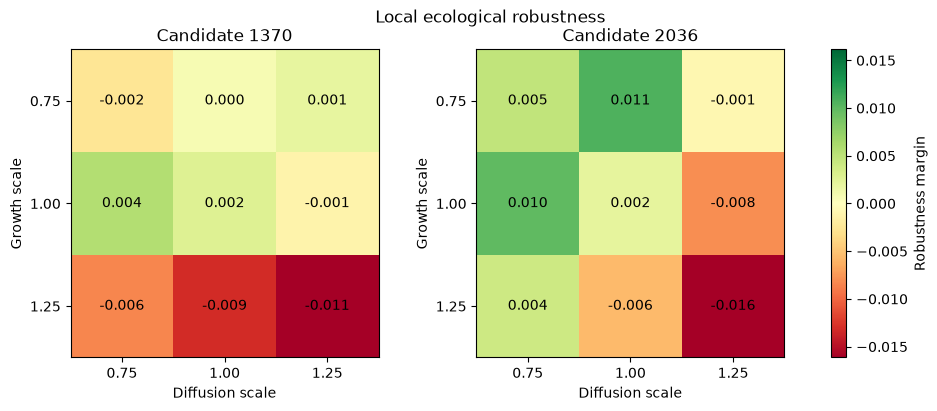

In [8]:
if not deterministic_summary.empty:
    ecology = deterministic_summary[
        deterministic_summary["scenario_type"] == "ecology"
    ].copy()
    ecology = ecology.merge(
        candidates[["sample_id", "growth_rate", "diffusion_rate"]].rename(
            columns={"growth_rate": "base_growth", "diffusion_rate": "base_diffusion"}
        ),
        on="sample_id",
    )
    ecology["growth_scale"] = ecology["growth_rate"] / ecology["base_growth"]
    ecology["diffusion_scale"] = ecology["diffusion_rate"] / ecology["base_diffusion"]

    fig, axes = plt.subplots(1, len(candidates), figsize=(6 * len(candidates), 4), squeeze=False)
    for ax, (sample_id, group) in zip(axes.flat, ecology.groupby("sample_id")):
        pivot = group.pivot(index="growth_scale", columns="diffusion_scale", values="robustness_margin")
        image = ax.imshow(pivot, cmap="RdYlGn", vmin=-abs(pivot.to_numpy()).max(), vmax=abs(pivot.to_numpy()).max())
        ax.set_xticks(range(len(pivot.columns)), [f"{value:.2f}" for value in pivot.columns])
        ax.set_yticks(range(len(pivot.index)), [f"{value:.2f}" for value in pivot.index])
        ax.set(xlabel="Diffusion scale", ylabel="Growth scale", title=f"Candidate {sample_id}")
        for row_index in range(len(pivot.index)):
            for column_index in range(len(pivot.columns)):
                ax.text(column_index, row_index, f"{pivot.iloc[row_index, column_index]:.3f}", ha="center", va="center")
    fig.colorbar(image, ax=axes.ravel().tolist(), label="Robustness margin")
    fig.suptitle("Local ecological robustness")
    plt.show()

## 5. Balanced random-schedule robustness

Each random schedule has the same near-equal number of A and B applications as the deterministic controls. This tests whether the result depends on the alternating order rather than merely mixing the two policies.

In [9]:
if random_path.exists():
    random_results = pd.read_csv(random_path)
else:
    random_results = pd.DataFrame()

completed_random = set()
if not random_results.empty:
    completed_random = set(
        random_results[["sample_id", "seed"]]
        .itertuples(index=False, name=None)
    )

if RUN_RANDOM:
    total = len(candidates) * RANDOM_REPLICATES
    with tqdm(total=total, desc="Balanced random schedules") as progress:
        for _, candidate in candidates.iterrows():
            config = experiment_config(candidate, BASELINE_STEPS)
            parameters = policy_parameters(candidate)
            for seed in range(RANDOM_REPLICATES):
                key = (int(candidate["sample_id"]), seed)
                if key not in completed_random:
                    schedule = balanced_random_schedule(config.steps, seed)
                    result = run_experiment(
                        name=f"step10_{key[0]}_random_{seed}",
                        gdf=metro,
                        config=config,
                        policy=make_scheduled_policy(
                            schedule, parameters, float(candidate["budget"])
                        ),
                    )
                    row = result_row(
                        candidate, "random", f"seed_{seed}", "random", config, result
                    )
                    row["seed"] = seed
                    row["switches"] = int(np.sum(np.asarray(schedule[1:]) != np.asarray(schedule[:-1])))
                    random_results = pd.concat(
                        [random_results, pd.DataFrame([row])], ignore_index=True
                    )
                    random_results.to_csv(random_path, index=False)
                    completed_random.add(key)
                progress.update(1)

print(f"Random-schedule rows available: {len(random_results)}")

Balanced random schedules: 100%|██████████| 400/400 [01:58<00:00,  3.37it/s]

Random-schedule rows available: 400


,sample_id,schedules,winning_fraction,median_change,minimum_change,maximum_change
0,1370,200,0.550,-0.000775,-0.009343,0.018498
1,2036,200,0.525,-0.000194,-0.011040,0.015704


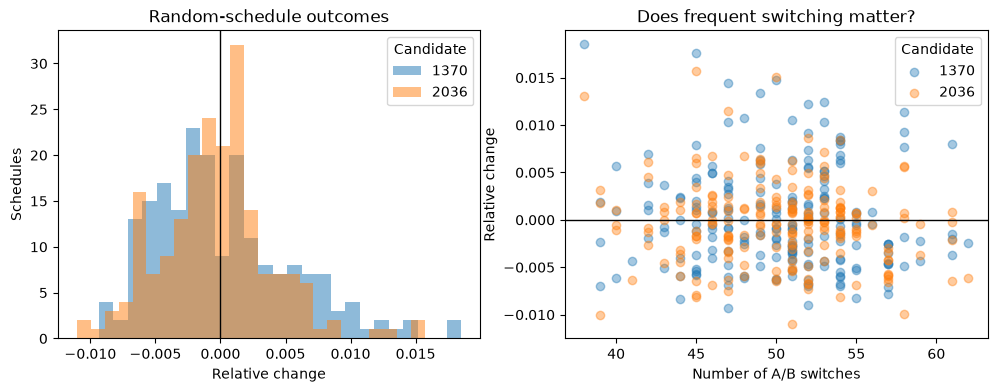

In [10]:
if random_results.empty:
    print("No random results yet. Set RUN_RANDOM = True and rerun.")
else:
    random_summary = (
        random_results.groupby("sample_id")
        .agg(
            schedules=("seed", "count"),
            winning_fraction=("winning", "mean"),
            median_change=("relative_change", "median"),
            minimum_change=("relative_change", "min"),
            maximum_change=("relative_change", "max"),
        )
        .reset_index()
    )
    display(random_summary)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for sample_id, group in random_results.groupby("sample_id"):
        axes[0].hist(group["relative_change"], bins=25, alpha=0.5, label=sample_id)
        axes[1].scatter(group["switches"], group["relative_change"], alpha=0.4, label=sample_id)
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set(xlabel="Relative change", ylabel="Schedules", title="Random-schedule outcomes")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set(xlabel="Number of A/B switches", ylabel="Relative change", title="Does frequent switching matter?")
    for ax in axes:
        ax.legend(title="Candidate")
    plt.show()

## Interpretation and hand-off to Step 11

A candidate should be carried forward when it has: (1) a positive deterministic robustness margin across multiple durations, (2) a contiguous positive region around the baseline ecology rather than one isolated cell, and (3) AB/BA performance that is unusually good relative to balanced random schedules.

Failure is also informative. A duration-only failure suggests a transient effect; an ecology failure identifies a narrow parameter regime; and a high random winning fraction means mixing, not alternation, is the important feature. Step 11 should use the strongest surviving candidate to measure the proposed A-to-B threshold handoff directly.